In [ ]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded=files.upload()


Saving cleaned_netflix.csv to cleaned_netflix (2).csv


In [ ]:
df = pd.read_csv("cleaned_netflix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,duration_value,duration_type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,90,min
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,2,Seasons
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,1,Season
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Not Available,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,1,Season
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,2,Seasons


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8794 entries, 0 to 8793
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   show_id         8794 non-null   object
 1   type            8794 non-null   object
 2   title           8794 non-null   object
 3   director        8794 non-null   object
 4   cast            8794 non-null   object
 5   country         8794 non-null   object
 6   date_added      8794 non-null   object
 7   release_year    8794 non-null   int64 
 8   rating          8790 non-null   object
 9   duration        8794 non-null   object
 10  listed_in       8794 non-null   object
 11  description     8794 non-null   object
 12  year_added      8794 non-null   int64 
 13  duration_value  8794 non-null   int64 
 14  duration_type   8794 non-null   object
dtypes: int64(3), object(12)
memory usage: 1.0+ MB


In [ ]:
df.describe()

,release_year,year_added,duration_value
count,8794.000000,8794.000000,8794.000000
mean,2014.183534,2018.872754,69.920173
std,8.823527,1.573789,50.797005
min,1925.000000,2008.000000,1.000000
25%,2013.000000,2018.000000,2.000000
50%,2017.000000,2019.000000,88.000000
75%,2019.000000,2020.000000,106.000000
max,2021.000000,2021.000000,312.000000


In [ ]:
df['type'].value_counts()

,count
type,
Movie,6128
Tv Show,2666


In [ ]:
### Observations:
# - Dataset contains Movies and TV Shows
# - Majority content type can be identified using value_counts()

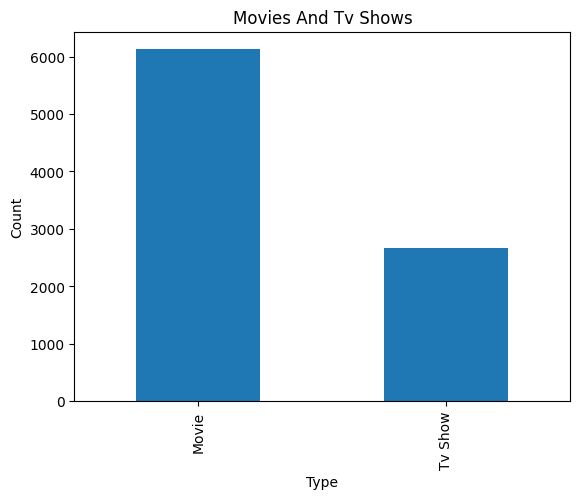

In [ ]:
df['type'].value_counts().plot(kind='bar')
plt.title("Movies And Tv Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

In [ ]:
# ### Observations:
# - Dataset contains Movies and TV Shows
# - Majority content type can be identified using value_counts()

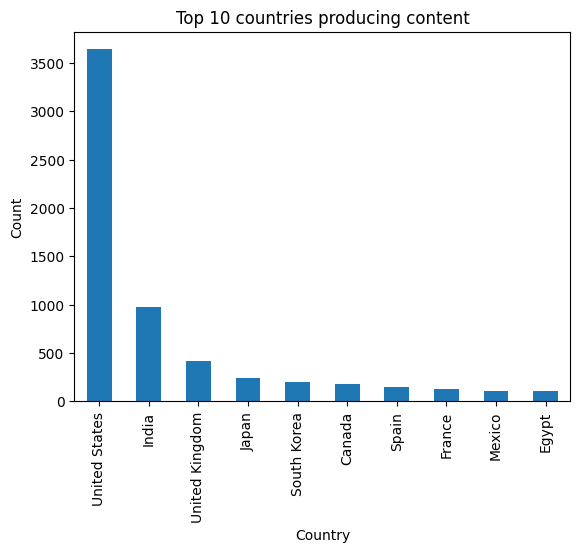

In [ ]:
top_country=df['country'].value_counts().head(10)

top_country.plot(kind='bar')
plt.title("Top 10 countries producing content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

In [ ]:
# United States produces the highest content.

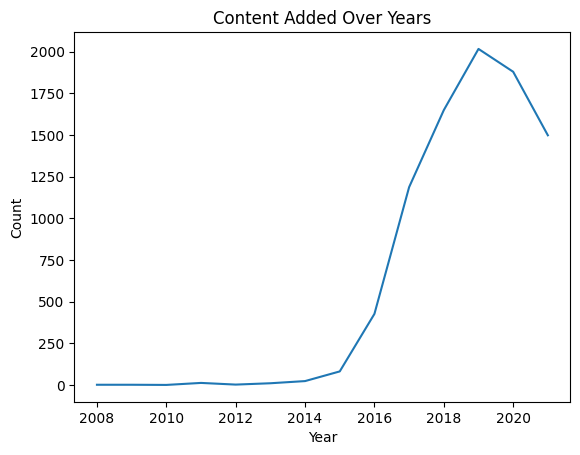

In [ ]:
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

In [ ]:
# Content increased rapidly after 2015.

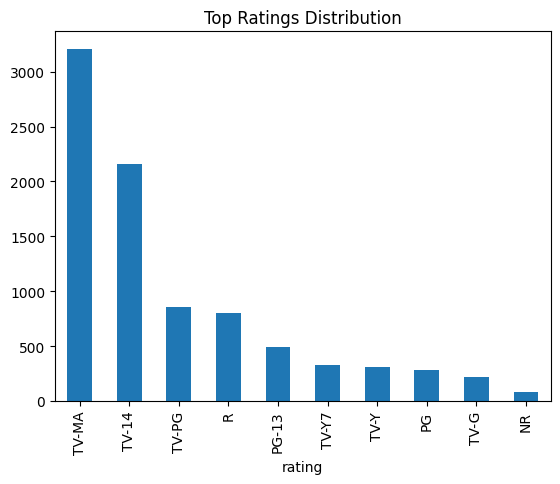

In [ ]:
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title("Top Ratings Distribution")
plt.show()

In [ ]:
# TV-MA and TV-14 are most common ratings.

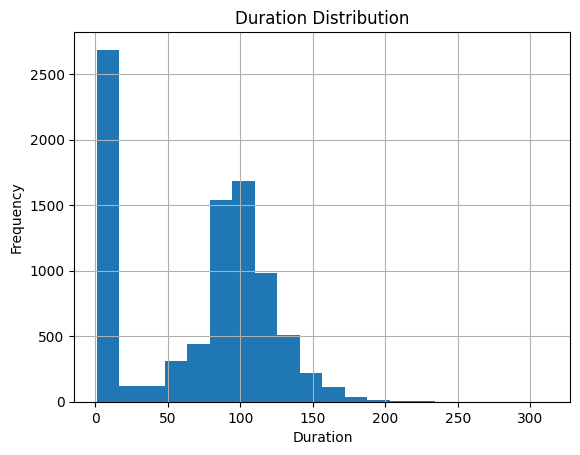

In [ ]:
df['duration_value'].hist(bins=20)
plt.title("Duration Distribution")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Most movies have duration around 80–120 minutes.

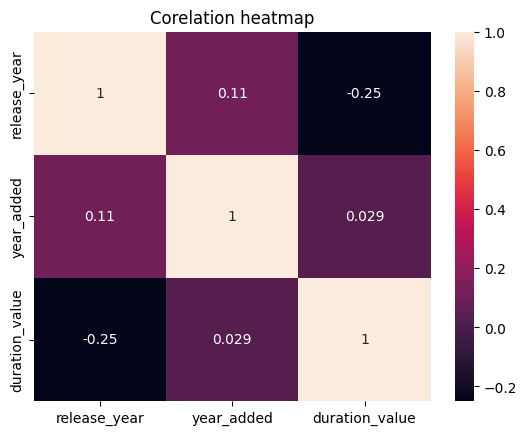

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("Corelation heatmap")
plt.show()

In [ ]:
# Weak correlation between numerical features.

In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

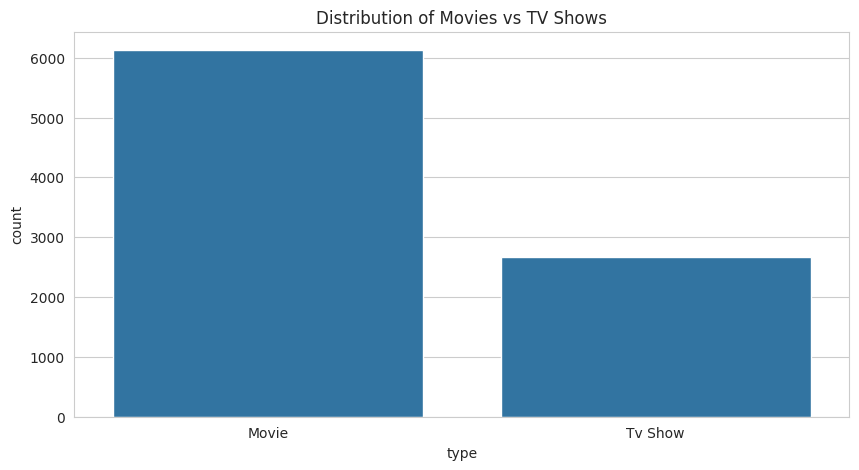

In [ ]:
sns.countplot(x='type', data=df)
plt.title("Distribution of Movies vs TV Shows")
plt.show()

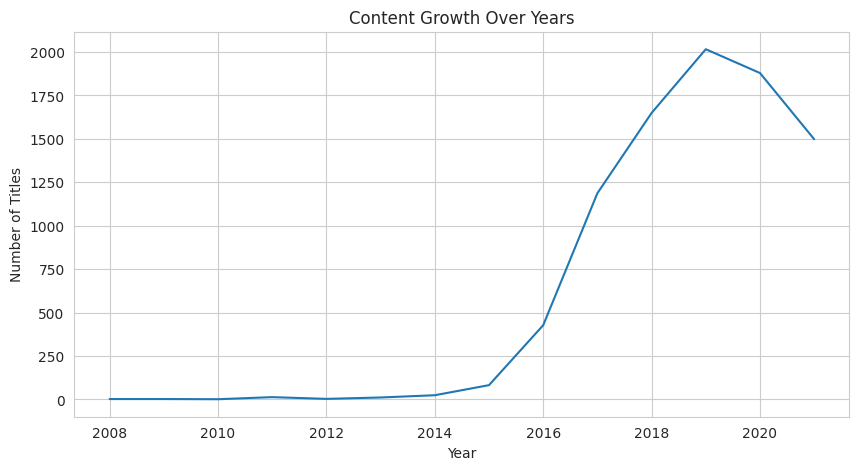

In [ ]:
year_data = df['year_added'].value_counts().sort_index()

sns.lineplot(x=year_data.index, y=year_data.values)
plt.title("Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

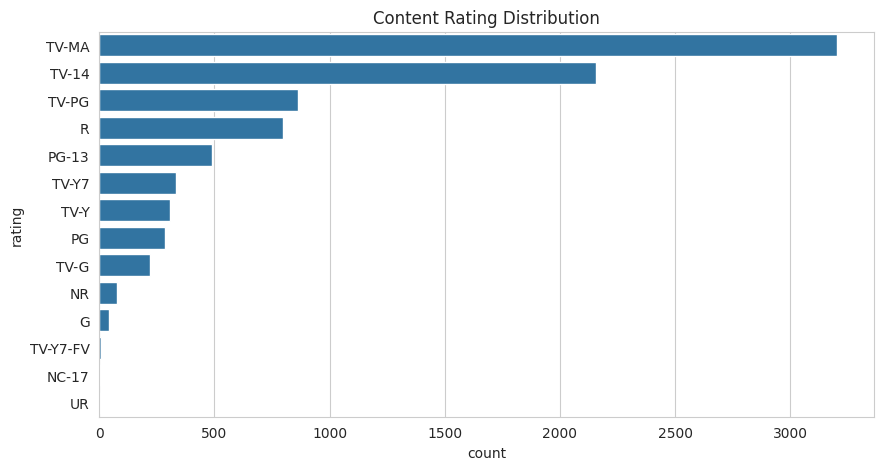

In [ ]:
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title("Content Rating Distribution")
plt.show()

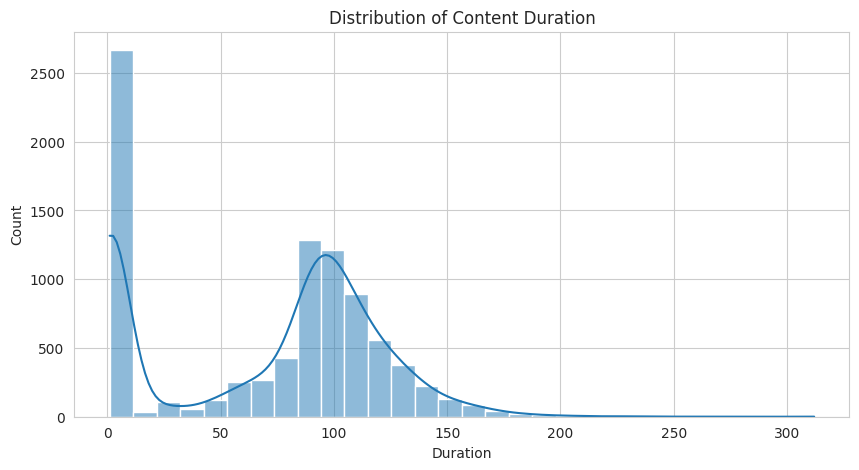

In [ ]:
sns.histplot(df['duration_value'], bins=30, kde=True)
plt.title("Distribution of Content Duration")
plt.xlabel("Duration")
plt.show()

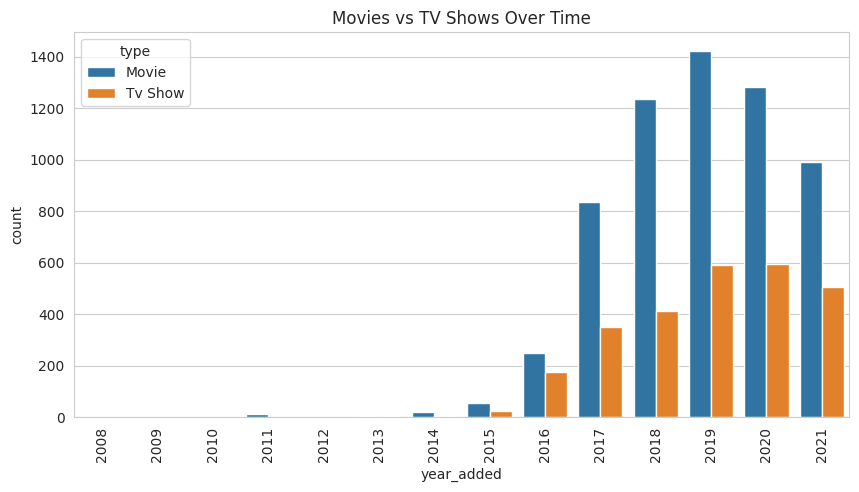

In [ ]:
sns.countplot(x='year_added', hue='type', data=df)
plt.xticks(rotation=90)
plt.title("Movies vs TV Shows Over Time")
plt.show()

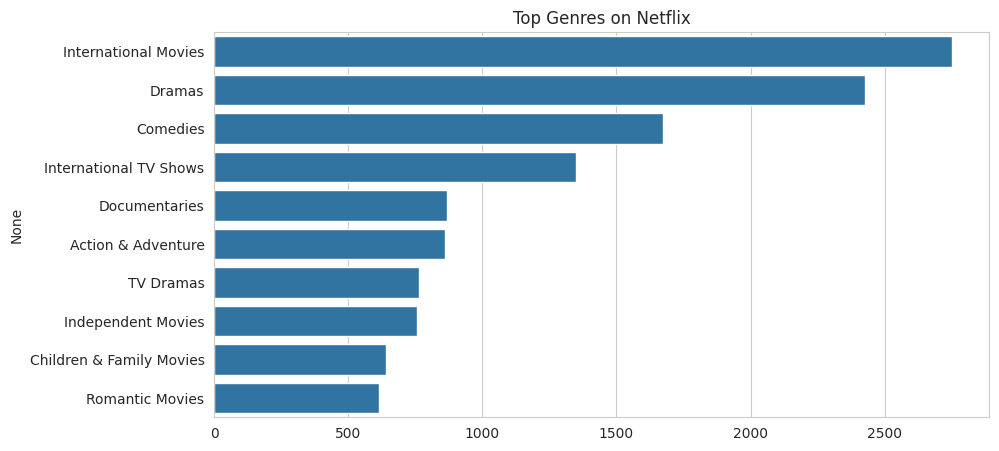

In [ ]:
genres = df['listed_in'].str.split(', ', expand=True).stack()
top_genres = genres.value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top Genres on Netflix")
plt.show()